<a href="https://colab.research.google.com/github/noruzzaman-rahat/Research-With-Machine-Learning/blob/main/Lecture6_Data_Preprocessing_assingmen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>

# 🌾 Lecture #6 — Python for ML Research
## Data Preprocessing: From Raw Agricultural Data to ML-Ready Pipeline



### 📑 Table of Contents

| # | Title |
|---|-------|
| 1 | Library Setup |
| 2 | Data Import |
| 3 | Data Exploration |
| 4 | Inject Missing Values (Teaching Utility) |
| 5 | Data Cleaning — Missing Values, Duplicates |
| 6 | Visualization — Distributions & Correlation |
| 7 | Encoding Categorical Data |
| 8 | Scaling & Normalization |
| 9 | Train-Test Split |
| 10 | Activity — Full Preprocessing Pipeline |
| 11 | Summary |

###Titanic - Machine Learning from Disaster(Data sets)

## Cell 1 | Library Setup

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2 | Data Import

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/skill morph/Titanic - Machine Learning from Disaster/test.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Cell 3 | Data Exploration

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Cell 4 | Inject Missing Values

The original Kaggle dataset has **no missing values**.  
We **artificially inject** NaNs to practice `fillna()`.



In [7]:


# Confirm zero NaNs
print(df.isnull().sum().sum())   # should print 0



414


In [9]:
inject = {'Age': 10, 'Fare': 5, 'Embarked': 2}
# Now inject safely
np.random.seed(42)
for col, n in inject.items():
    idx = np.random.choice(df.index, size=n, replace=False)
    df.loc[idx, col] = np.nan

# Verify
df.isnull().sum()[df.isnull().sum() > 0]

,0
Age,95
Fare,6
Cabin,327
Embarked,2


## Cell 5 | Data Cleaning — Missing Values, Duplicates

### 5a — Fill Missing Values

In [11]:
# Numeric → median; Categorical → mode (most frequent)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

df.isnull().sum().sum()  # should be 0

np.int64(0)

### 5b — Duplicates

In [12]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (418, 11)


## Cell 6 | Visualization — Distributions & Correlation

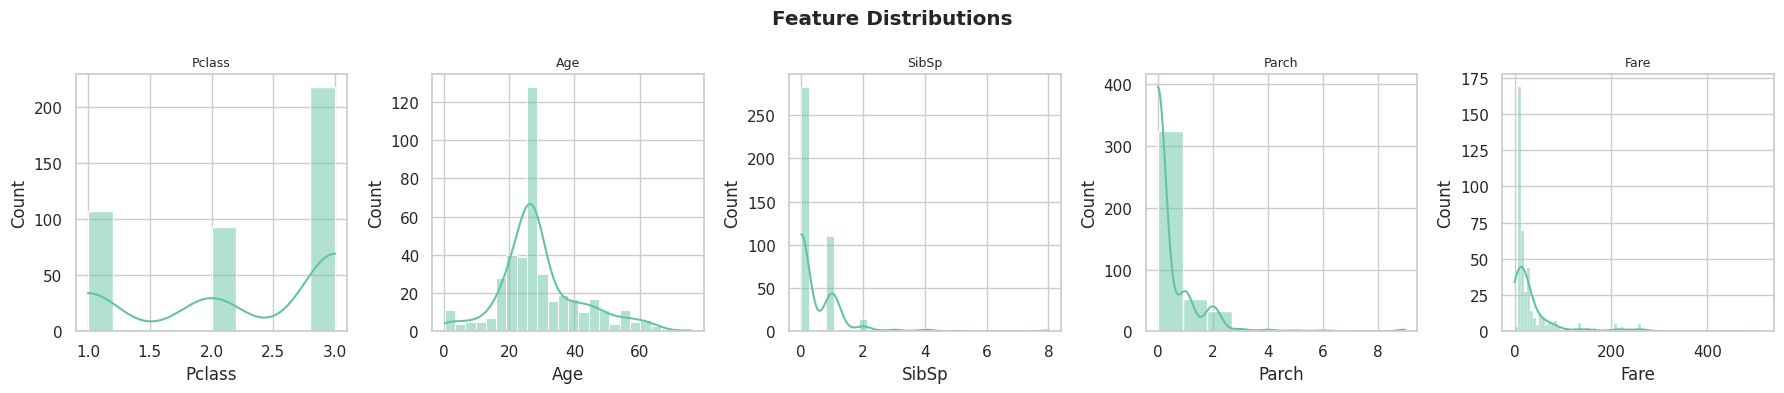

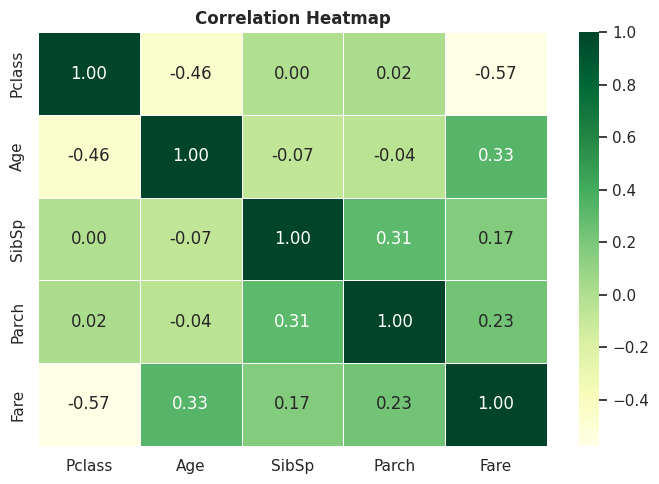

In [14]:
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col, fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold'); plt.tight_layout(); plt.show()

## Cell 7 | Encoding Categorical Data

In [16]:
cat_cols = ['Sex', 'Embarked', 'Cabin']
df_enc = df.drop(columns=['PassengerId']).copy()

# Label Encoding — best for tree-based models
le = LabelEncoder()
df_enc['Sex_LE'] = le.fit_transform(df_enc['Sex'])
df_enc.head(10)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_LE
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,B57 B59 B63 B66,Q,1
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,B57 B59 B63 B66,S,0
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,B57 B59 B63 B66,Q,1
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,B57 B59 B63 B66,S,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,B57 B59 B63 B66,S,0
5,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,B57 B59 B63 B66,S,1
6,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,B57 B59 B63 B66,Q,0
7,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,B57 B59 B63 B66,S,1
8,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,B57 B59 B63 B66,C,0
9,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,B57 B59 B63 B66,S,1


In [17]:
# One-Hot Encoding — best for linear / neural models
df_ohe = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_ohe.head(3)

,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_LE,Sex_male,Embarked_Q,...,Cabin_E52,Cabin_E60,Cabin_F,Cabin_F E46,Cabin_F E57,Cabin_F G63,Cabin_F2,Cabin_F33,Cabin_F4,Cabin_G6
0,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,1,True,True,...,False,False,False,False,False,False,False,False,False,False
1,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,1,True,True,...,False,False,False,False,False,False,False,False,False,False


## Cell 8 | Scaling & Normalization

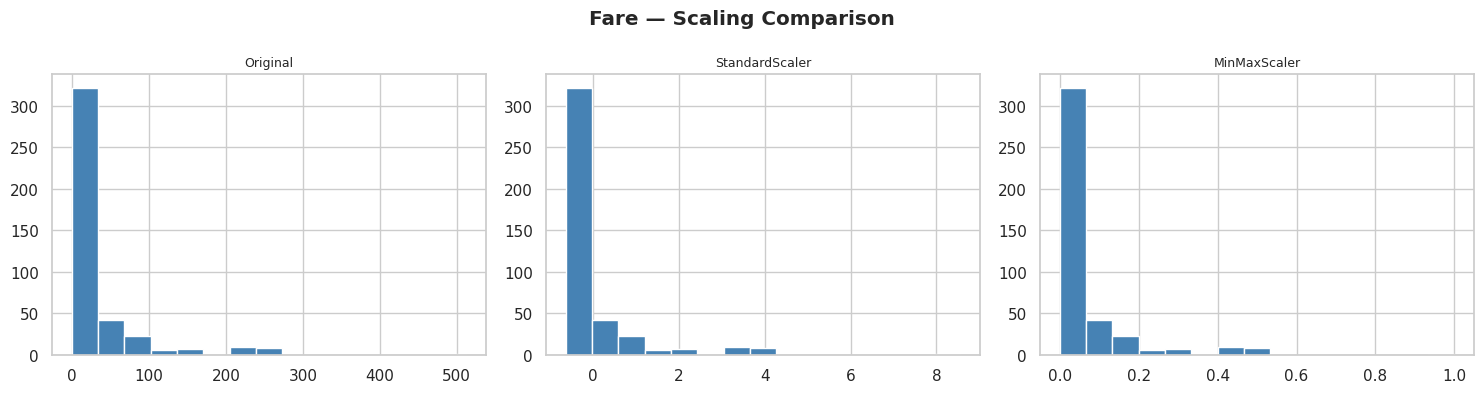

In [19]:
X_num = df[num_cols].copy()
yield_idx = num_cols.index('Fare') # Changed from 'Yield(tons)' to 'Fare'

scalers = {
    'Original'       : X_num['Fare'], # Changed from 'Yield(tons)' to 'Fare'
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, yield_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, yield_idx])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('Fare — Scaling Comparison', fontweight='bold'); plt.tight_layout(); plt.show()

## Cell 9 | Train-Test Split

X_train: (712, 155)  |  X_test: (179, 155)


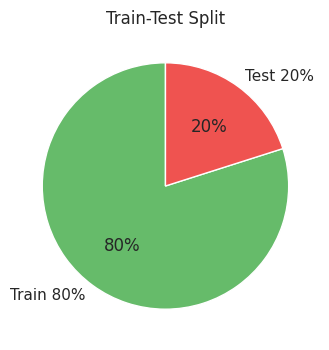

In [23]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the training data for the train-test split
df = pd.read_csv('/content/drive/MyDrive/skill morph/Titanic - Machine Learning from Disaster/train.csv')

# --- Re-apply preprocessing steps to the newly loaded df (from train.csv) ---

# 1. Inject Missing Values (mimicking Zq0ldwCkxb1F)
# Assuming 'inject' dict is available from earlier execution or define it if running standalone
if 'inject' not in globals():
    inject = {'Age': 10, 'Fare': 5, 'Embarked': 2} # Default if not defined globally

np.random.seed(42) # Ensure reproducibility of NaN injection
for col, n in inject.items():
    if col in df.columns: # Only inject if column exists in the current df
        # Ensure there are enough rows to sample without replacement
        if len(df) >= n:
            idx = np.random.choice(df.index, size=n, replace=False)
            df.loc[idx, col] = np.nan
        else:
            print(f"Warning: Not enough rows in df to inject {n} NaNs into {col}")

# 2. Fill Missing Values (mimicking cell-5a)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

# 3. Handle Duplicates (mimicking cell-5b)
df.drop_duplicates(inplace=True)

# 4. Encoding Categorical Data (mimicking cell-7 and P0HklFDs0DaX)
# Drop 'PassengerId', 'Name', 'Ticket' as they are typically not used as direct features
df_processed = df.drop(columns=['PassengerId', 'Name', 'Ticket']).copy()

# Label encode 'Sex'
le = LabelEncoder()
df_processed['Sex_LE'] = le.fit_transform(df_processed['Sex'])

# One-hot encode other categorical columns
# Note: This will create new 'Sex_male'/'Sex_female' columns while 'Sex_LE' also exists, similar to original df_ohe structure.
df_ohe = pd.get_dummies(df_processed, columns=['Sex', 'Embarked', 'Cabin'], drop_first=True)

# Now df_ohe should contain the 'Survived' column, as it was generated from train.csv
X = df_ohe.drop(columns=['Survived'], errors='ignore')
y = df_ohe['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split'); plt.show()

## Cell 10 | Activity — Full Preprocessing Pipeline

## Cell 11 | Summary

| Step | Method | Key Rule |
|------|--------|----------|
| Import | `pd.read_csv()` | Load from Drive path |
| Explore | `.info()`, `.describe()` | Understand before touching |
| Missing Values | `.fillna(median/mean/mode)` | Median for skewed, mean for normal, mode for categorical |
| Duplicates | `.drop_duplicates()` | Always remove first |
| Outliers | IQR method | Boxplot to confirm |
| Label Encoding | `LabelEncoder` | Tree-based models |
| One-Hot Encoding | `pd.get_dummies()` | Linear / Neural models |
| StandardScaler | Z-score | SVM, PCA, LogReg |
| MinMaxScaler | [0, 1] range | Neural Networks, KNN |
| RobustScaler | IQR-based | Outlier-heavy data |
| Split | `train_test_split` | Fit scaler on **train only** |

---

### 🚀 Next — Lecture #6: Feature Engineering & Selection
- Creating new features from existing ones  
- Filter, Wrapper, Embedded selection methods  
- PCA, t-SNE, UMAP for dimensionality reduction

<div align='center'>

> *"Clean data is not an accident — it is the result of intentional effort."*  
> **— Skill Morph Research Lab**

</div>